<a href="https://colab.research.google.com/github/RAVIAPTISWETHA/COVID-19-Detection-from-Chest-X-ray-Images-Using-CNN-/blob/main/Final_Project_File.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Libraries


In [ ]:
pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 13.2 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
import os
from PIL import Image
import random
import hashlib
import shutil
import cv2
from sklearn.utils import class_weight
print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Dataset Path and Folder Check


In [ ]:
dataset_path = "/content/drive/MyDrive/Covid19-Pneumonia-Normal Chest X-Ray Images Dataset"

print("Folders inside dataset:\n")
print(os.listdir(dataset_path))

Folders inside dataset:

['COVID', 'PNEUMONIA', 'NORMAL']


# Count Images in Each Class

In [ ]:
for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        print(f"{class_name}: {num_images} images")

COVID: 1626 images
PNEUMONIA: 1800 images
NORMAL: 1802 images


# Remove Duplicate Images


In [ ]:
clean_dataset_path = "/content/drive/MyDrive/clean_dataset"
duplicates_path = "/content/drive/MyDrive/duplicate_images"

classes = ["COVID", "NORMAL", "PNEUMONIA"]


def is_already_processed(path, classes):
    if not os.path.exists(path):
        return False

    for cls in classes:
        class_path = os.path.join(path, cls)
        if not os.path.exists(class_path) or len(os.listdir(class_path)) == 0:
            return False
    return True


if is_already_processed(clean_dataset_path, classes):
    print("Dataset already cleaned. Skipping processing.")
else:
    print("Processing dataset (removing duplicates)...")

    for cls in classes:
        os.makedirs(os.path.join(clean_dataset_path, cls), exist_ok=True)
        os.makedirs(os.path.join(duplicates_path, cls), exist_ok=True)

    hash_dict = {}
    duplicates_count = 0

    for cls in classes:
        class_path = os.path.join(dataset_path, cls)

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            with open(img_path, 'rb') as f:
                file_hash = hashlib.md5(f.read()).hexdigest()


            if file_hash not in hash_dict:
                hash_dict[file_hash] = img_path
                shutil.copy(img_path, os.path.join(clean_dataset_path, cls, img_name))


            else:
                shutil.copy(img_path, os.path.join(duplicates_path, cls, img_name))
                duplicates_count += 1

    print("Done")
    print("Duplicates moved:", duplicates_count)

Dataset already cleaned. Skipping processing.


# Updated Class Counts


In [ ]:
print("\nCleaned Dataset Distribution:\n")

class_counts = {}
total_images = 0

for cls in os.listdir(clean_dataset_path):
    class_path = os.path.join(clean_dataset_path, cls)

    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        class_counts[cls] = count
        total_images += count
        print(f"{cls}: {count}")

print("\nTotal images:", total_images)


Cleaned Dataset Distribution:

COVID: 1537
NORMAL: 1671
PNEUMONIA: 1791

Total images: 4999


# Display Sample Images

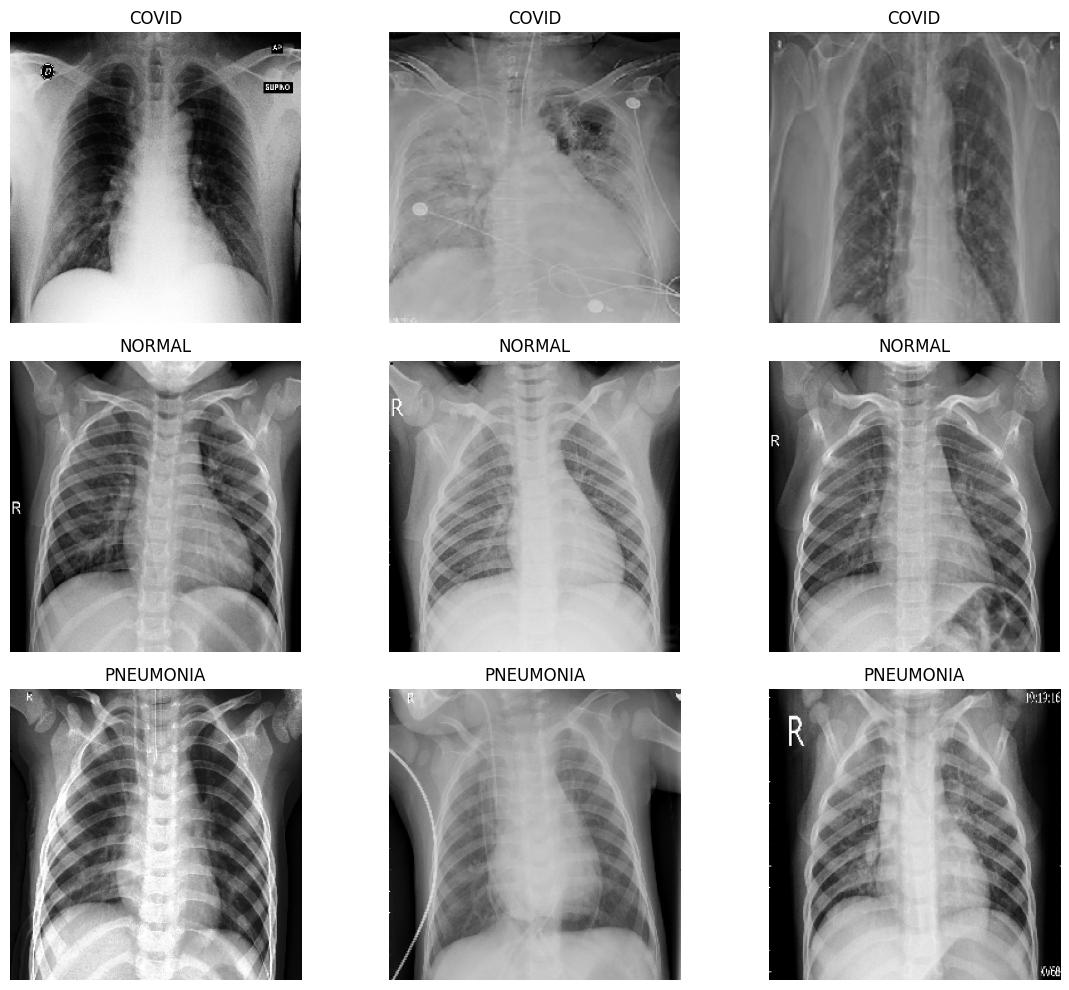

In [ ]:
classes = ["COVID", "NORMAL", "PNEUMONIA"]

plt.figure(figsize=(12,10))

plot_index = 1

for cls in classes:
    class_path = os.path.join(clean_dataset_path, cls)

    images = [img for img in os.listdir(class_path) if img.endswith(('.png', '.jpg', '.jpeg'))]

    sample_images = random.sample(images, 3)

    for img_name in sample_images:
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path).convert("RGB")

        plt.subplot(3, 3, plot_index)
        plt.imshow(img)
        plt.title(cls)
        plt.axis('off')

        plot_index += 1

plt.tight_layout()
plt.show()

# Bar Chart


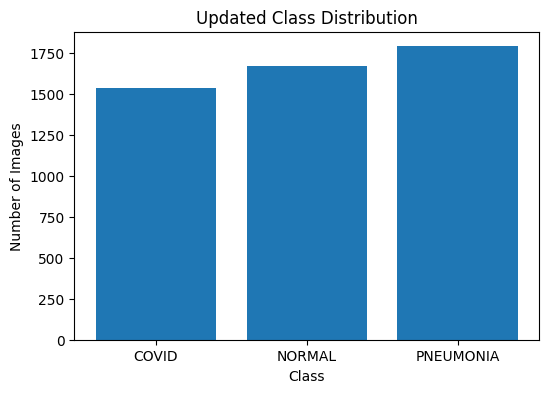

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Updated Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

# Pie Chart

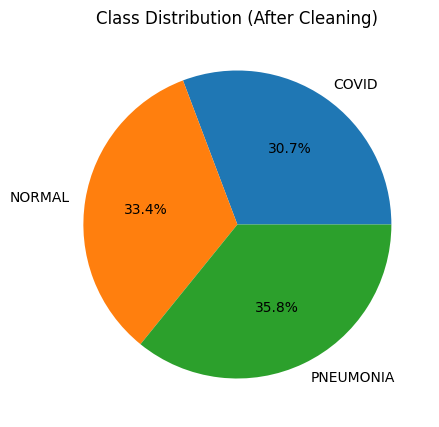

In [ ]:
plt.figure(figsize=(5,5))
plt.pie(class_counts.values(), labels=class_counts.keys(), autopct='%1.1f%%')
plt.title("Class Distribution (After Cleaning)")
plt.show()

# Image Size Check

In [ ]:
for cls in ["COVID", "NORMAL", "PNEUMONIA"]:
    class_path = os.path.join(dataset_path, cls)
    img_name = os.listdir(class_path)[0]
    img = Image.open(os.path.join(class_path, img_name))
    print(f"{cls} image size:", img.size)

COVID image size: (232, 232)
NORMAL image size: (256, 256)
PNEUMONIA image size: (256, 256)


# Pixel Intensity Histogram

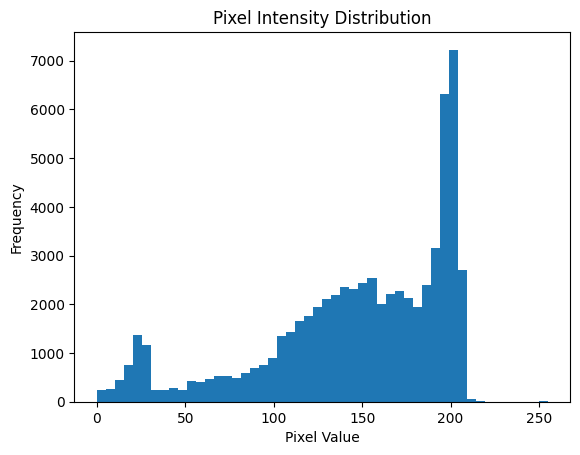

In [ ]:
img_array = np.array(img.convert("L"))

plt.hist(img_array.flatten(), bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

# Image Preprocessing and Data Generators


In [ ]:
base_dir = "/content/drive/MyDrive/clean_dataset"
split_base_path = "/content/covid_split"

train_path = os.path.join(split_base_path, "train")
val_path = os.path.join(split_base_path, "val")
test_path = os.path.join(split_base_path, "test")

classes = ["COVID", "NORMAL", "PNEUMONIA"]

img_size = (224, 224)
batch_size = 32


def is_split_ready(split_base_path, classes):
    for split in ["train", "val", "test"]:
        for cls in classes:
            path = os.path.join(split_base_path, split, cls)

            if not os.path.exists(path):
                return False

            if len(os.listdir(path)) == 0:
                return False

    return True



if is_split_ready(split_base_path, classes):
    print("Dataset split already exists. Skipping splitting step.")
else:
    print("Creating dataset split")

    # Create folders
    for split in ["train", "val", "test"]:
        for cls in classes:
            os.makedirs(os.path.join(split_base_path, split, cls), exist_ok=True)

    train_ratio = 0.7
    val_ratio = 0.15

    for cls in classes:
        class_path = os.path.join(base_dir, cls)
        images = [img for img in os.listdir(class_path)
                  if img.endswith(('.png', '.jpg', '.jpeg'))]

        random.shuffle(images)

        total = len(images)
        train_end = int(train_ratio * total)
        val_end = int((train_ratio + val_ratio) * total)

        train_imgs = images[:train_end]
        val_imgs = images[train_end:val_end]
        test_imgs = images[val_end:]

        for img in train_imgs:
            shutil.copy(os.path.join(class_path, img),
                        os.path.join(train_path, cls, img))

        for img in val_imgs:
            shutil.copy(os.path.join(class_path, img),
                        os.path.join(val_path, cls, img))

        for img in test_imgs:
            shutil.copy(os.path.join(class_path, img),
                        os.path.join(test_path, cls, img))

    print("Dataset split completed successfully.")

Dataset split already exists. Skipping splitting step.


# Data generators


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    val_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    test_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


print("\nClass indices:")
print(train_generator.class_indices)

x_batch, y_batch = next(train_generator)
print("\nImage batch shape:", x_batch.shape)
print("Label batch shape:", y_batch.shape)

Found 3497 images belonging to 3 classes.
Found 751 images belonging to 3 classes.
Found 751 images belonging to 3 classes.

Class indices:
{'COVID': 0, 'NORMAL': 1, 'PNEUMONIA': 2}

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 3)


# Apply Weights During Model Training

In [ ]:
class_labels = train_generator.classes

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(class_labels),
    y=class_labels
)

class_weights_dict = dict(enumerate(class_weights))

print("Calculated Class Weights:", class_weights_dict)

Calculated Class Weights: {0: np.float64(1.0843410852713178), 1: np.float64(0.9971485600228115), 2: np.float64(0.9303006118648577)}


# Baseline CNN Model


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

baseline_cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

baseline_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

# Train Baseline CNN Model


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

save_dir = "/content/drive/MyDrive/saved_models"
os.makedirs(save_dir, exist_ok=True)

baseline_checkpoint_dir = os.path.join(save_dir, "baseline_cnn", "checkpoints")
os.makedirs(baseline_checkpoint_dir, exist_ok=True)
best_model_path = os.path.join(baseline_checkpoint_dir, "best_baseline_cnn_model.keras")

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath=best_model_path,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False,
    mode='min',
    verbose=1
)

if os.path.exists(best_model_path):
    print(f"Baseline CNN model already found at {best_model_path}. Skipping training.")
    history_baseline_weighted = None
else:
    print("Training Baseline CNN model...")
    history_baseline_weighted = baseline_cnn.fit(
        train_generator,
        validation_data=val_generator,
        epochs=80,
        callbacks=[early_stopping, reduce_lr, checkpoint],
        class_weight=class_weights_dict
    )

Training Baseline CNN model...
Epoch 1/80
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.6259 - loss: 1.1196
Epoch 1: val_loss improved from None to 0.22396, saving model to /content/drive/MyDrive/saved_models/baseline_cnn/checkpoints/best_baseline_cnn_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/saved_models/baseline_cnn/checkpoints/best_baseline_cnn_model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 47s 389ms/step - accuracy: 0.7409 - loss: 0.6904 - val_accuracy: 0.9161 - val_loss: 0.2240 - learning_rate: 0.0010
Epoch 2/80
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.8607 - loss: 0.3792
Epoch 2: val_loss improved from 0.22396 to 0.18731, saving model to /content/drive/MyDrive/saved_models/baseline_cnn/checkpoints/best_baseline_cnn_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/saved_models/baseline_cnn/checkpoints/best_baseline_cnn_model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 40s 366ms/step - accuracy: 0.8602 - loss: 0.3732 - va

# Save Baseline CNN Model


In [ ]:
loaded_model = tf.keras.models.load_model(best_model_path)
print("Model loaded successfully from:", best_model_path)

Model loaded successfully from: /content/drive/MyDrive/saved_models/baseline_cnn/checkpoints/best_baseline_cnn_model.keras


# Evaluate Baseline CNN on Test Set


In [ ]:
test_loss, test_accuracy = loaded_model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.9680 - loss: 0.1320
Test Loss: 0.1319749504327774
Test Accuracy: 0.9680426120758057


# Confusion Matrix and Classification Report


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = baseline_cnn.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred_classes)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step
Confusion Matrix:
 [[226   2   3]
 [  3 241   7]
 [  2   7 260]]

Classification Report:

              precision    recall  f1-score   support

       COVID       0.98      0.98      0.98       231
      NORMAL       0.96      0.96      0.96       251
   PNEUMONIA       0.96      0.97      0.96       269

    accuracy                           0.97       751
   macro avg       0.97      0.97      0.97       751
weighted avg       0.97      0.97      0.97       751



# Plot Confusion Matrix (Heatmap)


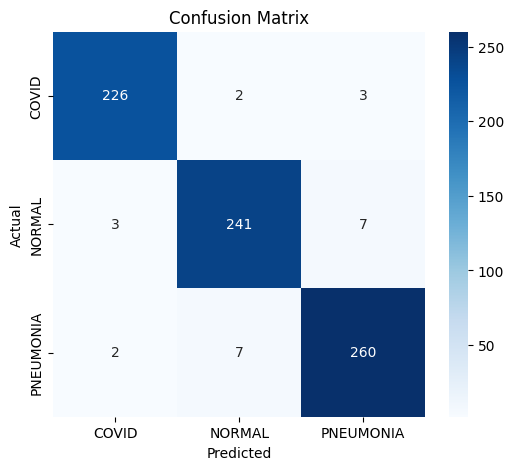

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Training vs Validation Accuracy


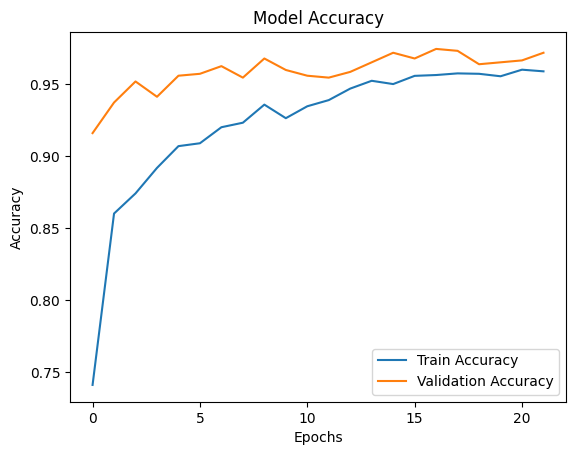

In [ ]:
if history_baseline_weighted:
    plt.plot(history_baseline_weighted.history['accuracy'], label='Train Accuracy')
    plt.plot(history_baseline_weighted.history['val_accuracy'], label='Validation Accuracy')

    plt.title("Model Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()
else:
    print("Training history not available for Baseline CNN (model was loaded from disk or training was skipped).")

# Training vs Validation Loss


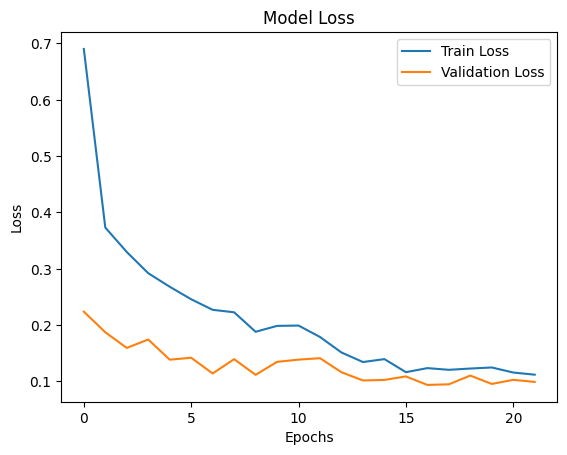

In [ ]:
if history_baseline_weighted:
    plt.plot(history_baseline_weighted.history['loss'], label='Train Loss')
    plt.plot(history_baseline_weighted.history['val_loss'], label='Validation Loss')

    plt.title("Model Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()
else:
    print("Training history not available for Baseline CNN (model was loaded from disk or training was skipped).")

In [ ]:
import keras_tuner as kt

def build_model(hp):
    model = Sequential()

    model.add(Conv2D(hp.Int('conv_1_filters', min_value=32, max_value=128, step=32),
                     (3, 3), activation='relu', input_shape=(224, 224, 3)))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(hp.Int('conv_2_filters', min_value=64, max_value=256, step=64),
                     (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    if hp.Boolean('use_third_conv'):
        model.add(Conv2D(hp.Int('conv_3_filters', min_value=128, max_value=512, step=128),
                         (3, 3), activation='relu'))
        model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())

    model.add(Dense(hp.Int('dense_units', min_value=64, max_value=256, step=64), activation='relu'))

    model.add(Dropout(hp.Float('dropout_rate', min_value=0.2, max_value=0.6, step=0.1)))

    model.add(Dense(3, activation='softmax'))

    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    optimizer = tf.keras.optimizers.Adam(learning_rate=hp_learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=20,
    factor=3,
    directory='keras_tuner_dir',
    project_name='covid_xray_tuning'
)

tuner.search_space_summary()

Reloading Tuner from keras_tuner_dir/covid_xray_tuning/tuner0.json
Search space summary
Default search space size: 7
conv_1_filters (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
conv_2_filters (Int)
{'default': None, 'conditions': [], 'min_value': 64, 'max_value': 256, 'step': 64, 'sampling': 'linear'}
use_third_conv (Boolean)
{'default': False, 'conditions': []}
dense_units (Int)
{'default': None, 'conditions': [], 'min_value': 64, 'max_value': 256, 'step': 64, 'sampling': 'linear'}
dropout_rate (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.2, 'max_value': 0.6, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}
conv_3_filters (Int)
{'default': None, 'conditions': [], 'min_value': 128, 'max_value': 512, 'step': 128, 'sampling': 'linear'}


In [ ]:
early_stopping_tuning = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_tuning = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

tuner.search(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[early_stopping_tuning, reduce_lr_tuning],
    class_weight=class_weights_dict
)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Optimal Hyperparameters:")
for hp_name, hp_value in best_hps.values.items():
    print(f"  {hp_name}: {hp_value}")

Trial 30 Complete [00h 00m 17s]

Best val_accuracy So Far: 0.9720372557640076
Total elapsed time: 02h 19m 30s
Optimal Hyperparameters:
  conv_1_filters: 32
  conv_2_filters: 64
  use_third_conv: False
  dense_units: 256
  dropout_rate: 0.2
  learning_rate: 0.001
  conv_3_filters: 512
  tuner/epochs: 20
  tuner/initial_epoch: 0
  tuner/bracket: 0
  tuner/round: 0


### Build and Train the Best Model

In [ ]:
best_model = tuner.hypermodel.build(best_hps)

best_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    47,776,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,796,163 (182.33 MB)

 Trainable params: 47,796,163 (182.33 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
tuned_checkpoint_dir = os.path.join(save_dir, "tuned_cnn", "checkpoints")
os.makedirs(tuned_checkpoint_dir, exist_ok=True)
best_model_path_tuned = os.path.join(tuned_checkpoint_dir, "best_tuned_cnn_model.keras")

checkpoint_tuned = ModelCheckpoint(
    filepath=best_model_path_tuned,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False,
    mode='min',
    verbose=1
)

if os.path.exists(best_model_path_tuned):
    print(f"Tuned model already found at {best_model_path_tuned}. Skipping training.")
    history_tuned = None
else:
    print("Training tuned model")
    history_tuned = best_model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=80,
        callbacks=[early_stopping, reduce_lr, checkpoint_tuned],
        class_weight=class_weights_dict
    )

Training tuned model
Epoch 1/80
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.6092 - loss: 2.3320
Epoch 1: val_loss improved from None to 0.21155, saving model to /content/drive/MyDrive/saved_models/tuned_cnn/checkpoints/best_tuned_cnn_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/saved_models/tuned_cnn/checkpoints/best_tuned_cnn_model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 47s 395ms/step - accuracy: 0.7484 - loss: 1.0042 - val_accuracy: 0.9348 - val_loss: 0.2116 - learning_rate: 0.0010
Epoch 2/80
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.8761 - loss: 0.3395
Epoch 2: val_loss improved from 0.21155 to 0.16941, saving model to /content/drive/MyDrive/saved_models/tuned_cnn/checkpoints/best_tuned_cnn_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/saved_models/tuned_cnn/checkpoints/best_tuned_cnn_model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 42s 380ms/step - accuracy: 0.8782 - loss: 0.3467 - val_accuracy: 0.9441 - val_loss: 0.1

### Evaluate the Tuned Model on Test Set

In [ ]:
loaded_tuned_model = tf.keras.models.load_model(best_model_path_tuned)
print("Tuned model loaded successfully from:", best_model_path_tuned)

test_loss_tuned, test_accuracy_tuned = loaded_tuned_model.evaluate(test_generator)

print("\nTest Loss (Tuned Model):", test_loss_tuned)
print("Test Accuracy (Tuned Model):", test_accuracy_tuned)

Tuned model loaded successfully from: /content/drive/MyDrive/saved_models/tuned_cnn/checkpoints/best_tuned_cnn_model.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.9121 - loss: 0.2435

Test Loss (Tuned Model): 0.2435256540775299
Test Accuracy (Tuned Model): 0.9121171832084656


### Confusion Matrix and Classification Report for Tuned Model

In [ ]:
y_pred_tuned = loaded_tuned_model.predict(test_generator)
y_pred_classes_tuned = np.argmax(y_pred_tuned, axis=1)

y_true_tuned = test_generator.classes

class_labels_tuned = list(test_generator.class_indices.keys())

cm_tuned = confusion_matrix(y_true_tuned, y_pred_classes_tuned)
print("Confusion Matrix (Tuned Model):\n", cm_tuned)

print("\nClassification Report (Tuned Model):\n")
print(classification_report(y_true_tuned, y_pred_classes_tuned, target_names=class_labels_tuned))

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step
Confusion Matrix (Tuned Model):
 [[218   4   9]
 [  8 228  15]
 [ 12  18 239]]

Classification Report (Tuned Model):

              precision    recall  f1-score   support

       COVID       0.92      0.94      0.93       231
      NORMAL       0.91      0.91      0.91       251
   PNEUMONIA       0.91      0.89      0.90       269

    accuracy                           0.91       751
   macro avg       0.91      0.91      0.91       751
weighted avg       0.91      0.91      0.91       751



### Plot Confusion Matrix (Heatmap) for Tuned Model

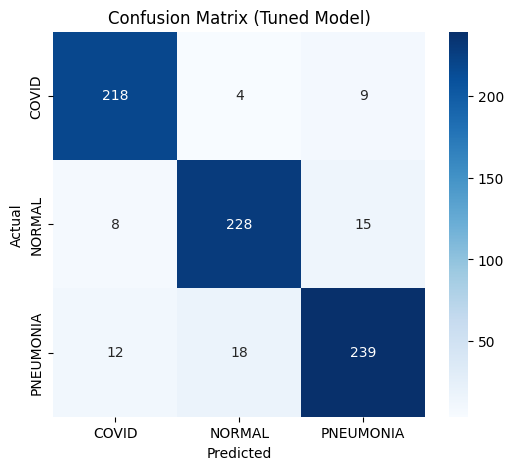

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels_tuned,
            yticklabels=class_labels_tuned)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Tuned Model)")
plt.show()

### Training vs Validation Accuracy for Tuned Model

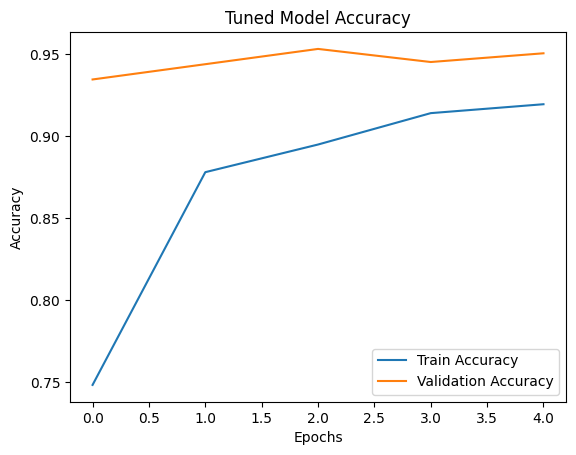

In [ ]:
if history_tuned:
    plt.plot(history_tuned.history['accuracy'], label='Train Accuracy')
    plt.plot(history_tuned.history['val_accuracy'], label='Validation Accuracy')

    plt.title("Tuned Model Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()
else:
    print("Training history not available for Tuned Model (model was loaded from disk or training was skipped).")

### Training vs Validation Loss for Tuned Model

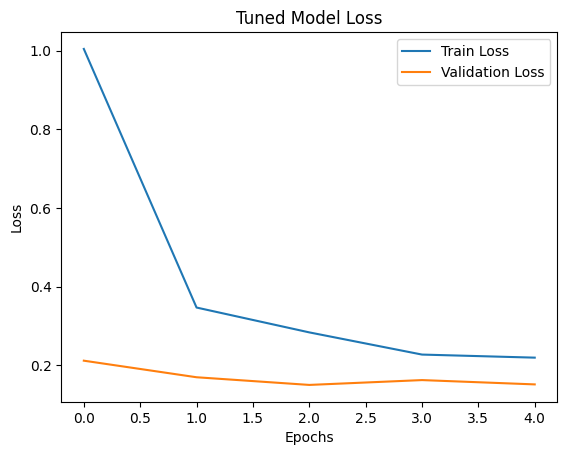

In [ ]:
if history_tuned:
    plt.plot(history_tuned.history['loss'], label='Train Loss')
    plt.plot(history_tuned.history['val_loss'], label='Validation Loss')

    plt.title("Tuned Model Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()
else:
    print("Training history not available for Tuned Model (model was loaded from disk or training was skipped).")

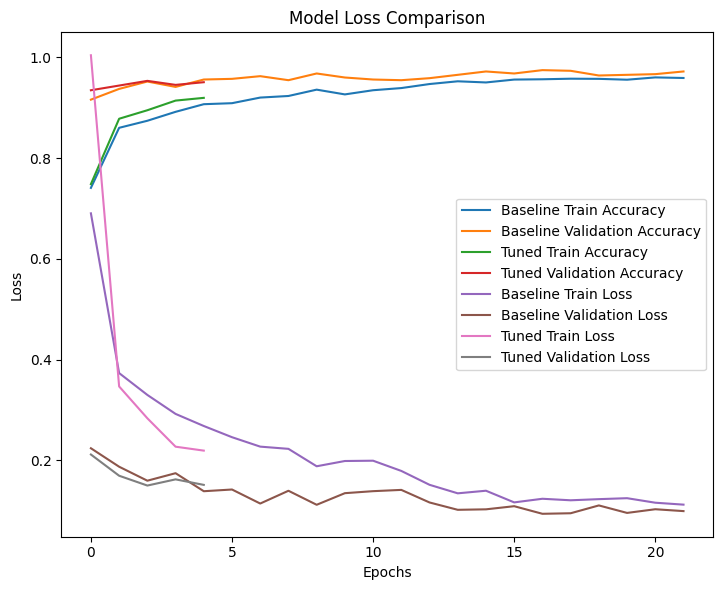

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
if history_baseline_weighted:
    plt.plot(history_baseline_weighted.history['accuracy'], label='Baseline Train Accuracy')
    plt.plot(history_baseline_weighted.history['val_accuracy'], label='Baseline Validation Accuracy')
if history_tuned:
    plt.plot(history_tuned.history['accuracy'], label='Tuned Train Accuracy')
    plt.plot(history_tuned.history['val_accuracy'], label='Tuned Validation Accuracy')

if history_baseline_weighted or history_tuned:
    plt.title("Model Accuracy Comparison")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
else:
    print("Training history not available for either Baseline CNN or Tuned Model (models were loaded from disk or training was skipped).")

if history_baseline_weighted:
    plt.plot(history_baseline_weighted.history['loss'], label='Baseline Train Loss')
    plt.plot(history_baseline_weighted.history['val_loss'], label='Baseline Validation Loss')
if history_tuned:
    plt.plot(history_tuned.history['loss'], label='Tuned Train Loss')
    plt.plot(history_tuned.history['val_loss'], label='Tuned Validation Loss')

if history_baseline_weighted or history_tuned:
    plt.title("Model Loss Comparison")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

plt.tight_layout()
plt.show()

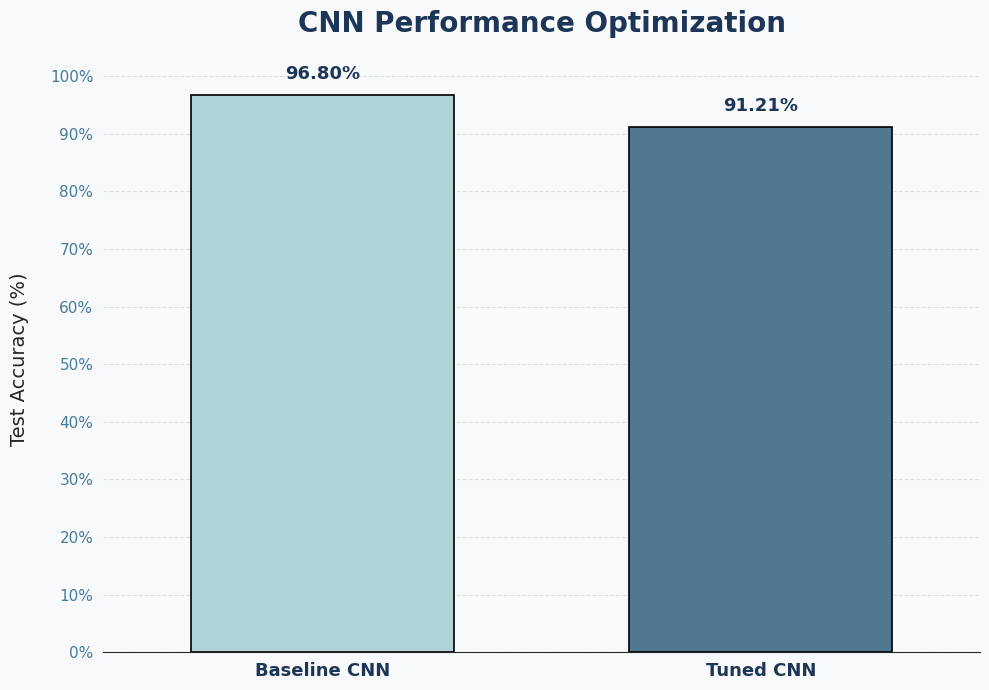

In [ ]:
model_names = ['Baseline CNN', 'Tuned CNN']
accuracies = [test_accuracy, test_accuracy_tuned]

sns.set_style("white")
plt.figure(figsize=(10, 7), facecolor='#F8F9FA')
ax = plt.gca()
ax.set_facecolor('#F8F9FA')
colors = ["#A8DADC", "#457B9D"]

barplot = sns.barplot(
    x=model_names,
    y=accuracies,
    hue=model_names,
    palette=colors,
    edgecolor='black',
    linewidth=1.2,
    legend=False,
    width=0.6
)

plt.title('CNN Performance Optimization', fontsize=20, fontweight='bold', pad=25, color='#1D3557')
plt.ylabel('Test Accuracy (%)', fontsize=14, labelpad=15, fontweight='500')
plt.xlabel('', fontsize=0)

plt.yticks(np.arange(0, 1.1, 0.1), [f'{x*100:.0f}%' for x in np.arange(0, 1.1, 0.1)], fontsize=11, color='#457B9D')
plt.xticks(fontsize=13, fontweight='bold', color='#1D3557')

ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.2)
sns.despine(left=True, bottom=False)

for p in barplot.patches:
    val = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2.,
        val + 0.02,
        f'{val:.2%}',
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight='bold',
        color='#1D3557'
    )
plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D

densenet = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

for layer in densenet.layers:
    layer.trainable = False

densenet_model = Sequential([
    densenet,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

densenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

densenet_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,300,675 (27.85 MB)

 Trainable params: 263,171 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
print("Training DenseNet121 model...")

densenet_checkpoint_dir = os.path.join(save_dir, "densenet121", "checkpoints")
os.makedirs(densenet_checkpoint_dir, exist_ok=True)
best_densenet_model_path = os.path.join(densenet_checkpoint_dir, "best_densenet121_model.keras")


checkpoint_densenet = ModelCheckpoint(
    filepath=best_densenet_model_path,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False,
    mode='min',
    verbose=1
)

if os.path.exists(best_densenet_model_path):
    print(f"DenseNet121 model already found at {best_densenet_model_path}. Skipping training.")
    history_densenet = None
else:
    history_densenet = densenet_model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=80,
        callbacks=[early_stopping, reduce_lr, checkpoint_densenet],
        class_weight=class_weights_dict
    )

Training DenseNet121 model...
Epoch 1/80
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.7474 - loss: 0.6341
Epoch 1: val_loss improved from None to 0.24377, saving model to /content/drive/MyDrive/saved_models/densenet121/checkpoints/best_densenet121_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/saved_models/densenet121/checkpoints/best_densenet121_model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 107s 746ms/step - accuracy: 0.8459 - loss: 0.3899 - val_accuracy: 0.9041 - val_loss: 0.2438 - learning_rate: 0.0010
Epoch 2/80
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.9193 - loss: 0.2336
Epoch 2: val_loss improved from 0.24377 to 0.19140, saving model to /content/drive/MyDrive/saved_models/densenet121/checkpoints/best_densenet121_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/saved_models/densenet121/checkpoints/best_densenet121_model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 40s 365ms/step - accuracy: 0.9154 - loss: 0.2417 - val_accura

In [ ]:
loaded_densenet_model = tf.keras.models.load_model(best_densenet_model_path)
print("DenseNet121 model loaded successfully from:", best_densenet_model_path)

test_loss_densenet, test_accuracy_densenet = loaded_densenet_model.evaluate(test_generator)

print("\nTest Loss (DenseNet121 Model):", test_loss_densenet)
print("Test Accuracy (DenseNet121 Model):", test_accuracy_densenet)

DenseNet121 model loaded successfully from: /content/drive/MyDrive/saved_models/densenet121/checkpoints/best_densenet121_model.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 25s 427ms/step - accuracy: 0.9547 - loss: 0.1448

Test Loss (DenseNet121 Model): 0.14482709765434265
Test Accuracy (DenseNet121 Model): 0.954727053642273


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_densenet = loaded_densenet_model.predict(test_generator)
y_pred_classes_densenet = np.argmax(y_pred_densenet, axis=1)

y_true_densenet = test_generator.classes

class_labels_densenet = list(test_generator.class_indices.keys())

cm_densenet = confusion_matrix(y_true_densenet, y_pred_classes_densenet)
print("Confusion Matrix (DenseNet121 Model):\n", cm_densenet)

print("\nClassification Report (DenseNet121 Model):\n")
print(classification_report(y_true_densenet, y_pred_classes_densenet, target_names=class_labels_densenet))

24/24 ━━━━━━━━━━━━━━━━━━━━ 25s 575ms/step
Confusion Matrix (DenseNet121 Model):
 [[225   2   4]
 [  2 239  10]
 [  3  13 253]]

Classification Report (DenseNet121 Model):

              precision    recall  f1-score   support

       COVID       0.98      0.97      0.98       231
      NORMAL       0.94      0.95      0.95       251
   PNEUMONIA       0.95      0.94      0.94       269

    accuracy                           0.95       751
   macro avg       0.96      0.96      0.96       751
weighted avg       0.95      0.95      0.95       751



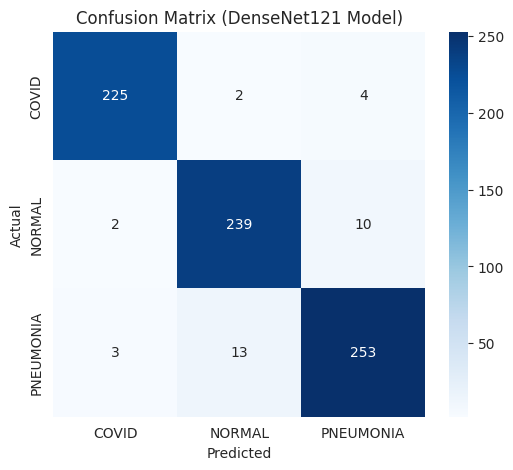

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(cm_densenet, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels_densenet,
            yticklabels=class_labels_densenet)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (DenseNet121 Model)")
plt.show()

### Training vs Validation Accuracy for DenseNet121 Model

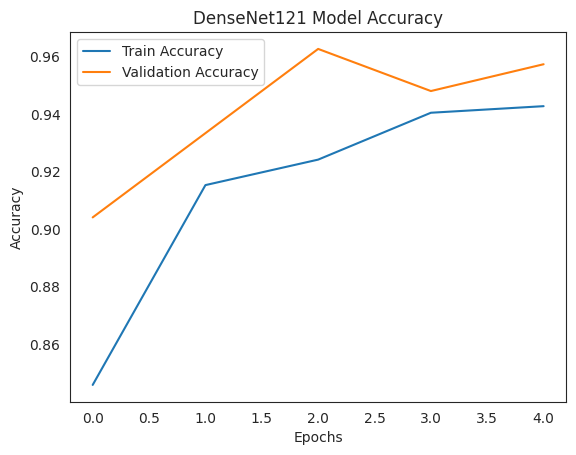

In [ ]:
if history_densenet:
    plt.plot(history_densenet.history['accuracy'], label='Train Accuracy')
    plt.plot(history_densenet.history['val_accuracy'], label='Validation Accuracy')

    plt.title("DenseNet121 Model Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()
else:
    print("Training history not available for DenseNet121 Model (model was loaded from disk or training was skipped).")

### Training vs Validation Loss for DenseNet121 Model

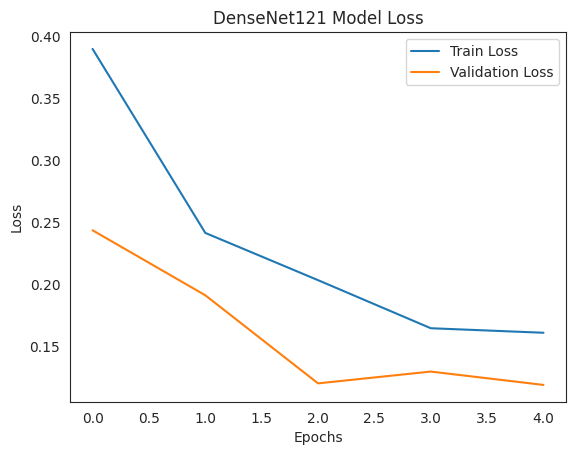

In [ ]:
if history_densenet:
    plt.plot(history_densenet.history['loss'], label='Train Loss')
    plt.plot(history_densenet.history['val_loss'], label='Validation Loss')

    plt.title("DenseNet121 Model Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()
else:
    print("Training history not available for DenseNet121 Model (model was loaded from disk or training was skipped).")

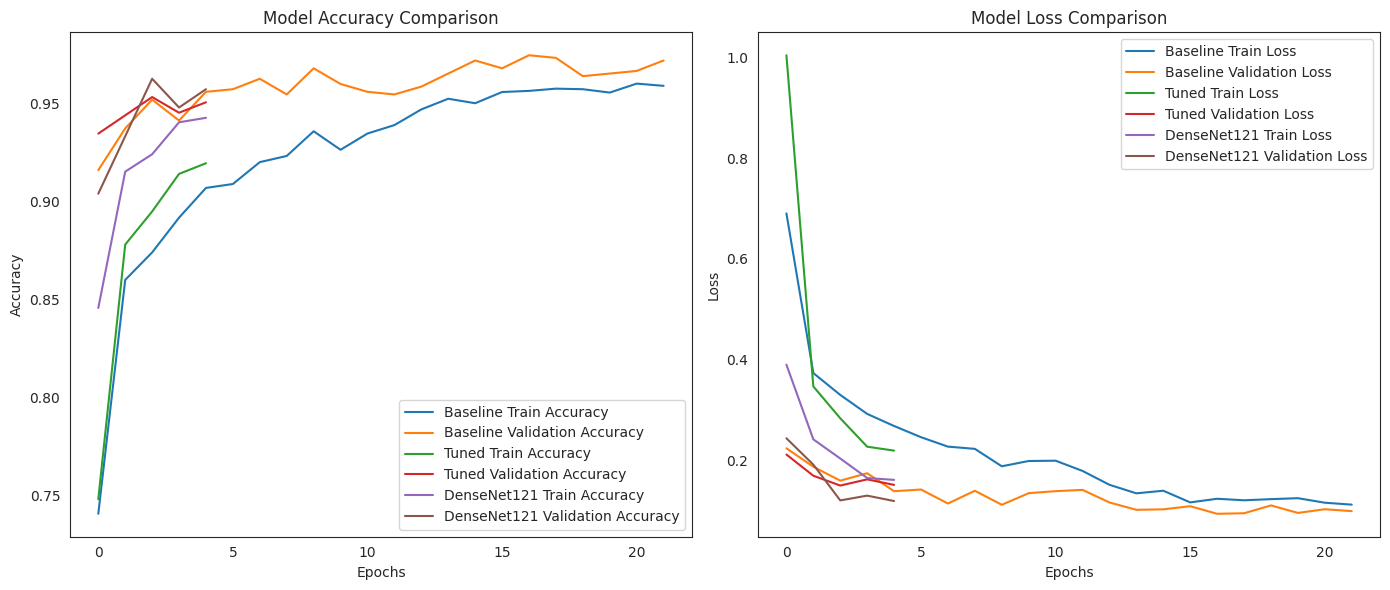

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
if history_baseline_weighted:
    plt.plot(history_baseline_weighted.history['accuracy'], label='Baseline Train Accuracy')
    plt.plot(history_baseline_weighted.history['val_accuracy'], label='Baseline Validation Accuracy')
if history_tuned:
    plt.plot(history_tuned.history['accuracy'], label='Tuned Train Accuracy')
    plt.plot(history_tuned.history['val_accuracy'], label='Tuned Validation Accuracy')
if history_densenet:
    plt.plot(history_densenet.history['accuracy'], label='DenseNet121 Train Accuracy')
    plt.plot(history_densenet.history['val_accuracy'], label='DenseNet121 Validation Accuracy')

if history_baseline_weighted or history_tuned or history_densenet:
    plt.title("Model Accuracy Comparison")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
else:
    print("Training history not available for any model (models were loaded from disk or training was skipped).")

plt.subplot(1, 2, 2)
if history_baseline_weighted:
    plt.plot(history_baseline_weighted.history['loss'], label='Baseline Train Loss')
    plt.plot(history_baseline_weighted.history['val_loss'], label='Baseline Validation Loss')
if history_tuned:
    plt.plot(history_tuned.history['loss'], label='Tuned Train Loss')
    plt.plot(history_tuned.history['val_loss'], label='Tuned Validation Loss')
if history_densenet:
    plt.plot(history_densenet.history['loss'], label='DenseNet121 Train Loss')
    plt.plot(history_densenet.history['val_loss'], label='DenseNet121 Validation Loss')

if history_baseline_weighted or history_tuned or history_densenet:
    plt.title("Model Loss Comparison")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
def build_densenet_model(hp):
    densenet_base = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    for layer in densenet_base.layers:
        layer.trainable = False

    model = Sequential([
        densenet_base,
        GlobalAveragePooling2D(),
        Dense(hp.Int('dense_units', min_value=128, max_value=512, step=128), activation='relu'),
        Dropout(hp.Float('dropout_rate', min_value=0.2, max_value=0.6, step=0.1)),
        Dense(3, activation='softmax')
    ])

    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    optimizer = tf.keras.optimizers.Adam(learning_rate=hp_learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
tuner_densenet = kt.Hyperband(
    build_densenet_model,
    objective='val_accuracy',
    max_epochs=20,
    factor=3,
    directory='keras_tuner_dir',
    project_name='densenet_tuning'
)

tuner_densenet.search_space_summary()

Search space summary
Default search space size: 3
dense_units (Int)
{'default': None, 'conditions': [], 'min_value': 128, 'max_value': 512, 'step': 128, 'sampling': 'linear'}
dropout_rate (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.2, 'max_value': 0.6, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}


In [ ]:
early_stopping_tuning_densenet = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_tuning_densenet = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

tuner_densenet.search(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[early_stopping_tuning_densenet, reduce_lr_tuning_densenet],
    class_weight=class_weights_dict
)

best_hps_densenet = tuner_densenet.get_best_hyperparameters(num_trials=1)[0]

print("\nOptimal Hyperparameters for DenseNet121 Classification Head:")
for hp_name, hp_value in best_hps_densenet.values.items():
    print(f"  {hp_name}: {hp_value}")

Trial 30 Complete [00h 13m 32s]
val_accuracy: 0.9693741798400879

Best val_accuracy So Far: 0.9720372557640076
Total elapsed time: 02h 44m 17s

Optimal Hyperparameters for DenseNet121 Classification Head:
  dense_units: 256
  dropout_rate: 0.2
  learning_rate: 0.01
  tuner/epochs: 20
  tuner/initial_epoch: 7
  tuner/bracket: 2
  tuner/round: 2
  tuner/trial_id: 0013


In [ ]:
best_densenet_tuned_model = tuner_densenet.hypermodel.build(best_hps_densenet)

best_densenet_tuned_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,300,675 (27.85 MB)

 Trainable params: 263,171 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
tuned_densenet_checkpoint_dir = os.path.join(save_dir, "tuned_densenet121", "checkpoints")
os.makedirs(tuned_densenet_checkpoint_dir, exist_ok=True)
best_tuned_densenet_model_path = os.path.join(tuned_densenet_checkpoint_dir, "best_tuned_densenet121_model.keras")

checkpoint_tuned_densenet = ModelCheckpoint(
    filepath=best_tuned_densenet_model_path,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False,
    mode='min',
    verbose=1
)

if os.path.exists(best_tuned_densenet_model_path):
    print(f"Tuned DenseNet121 model already found at {best_tuned_densenet_model_path}. Skipping training.")
    history_tuned_densenet = None
else:
    print("Training tuned DenseNet121 model...")
    history_tuned_densenet = best_densenet_tuned_model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=80,
        callbacks=[early_stopping_tuning_densenet, reduce_lr_tuning_densenet, checkpoint_tuned_densenet],
        class_weight=class_weights_dict
    )

Training tuned DenseNet121 model...
Epoch 1/80
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.6888 - loss: 2.7663
Epoch 1: val_loss improved from None to 0.20210, saving model to /content/drive/MyDrive/saved_models/tuned_densenet121/checkpoints/best_tuned_densenet121_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/saved_models/tuned_densenet121/checkpoints/best_tuned_densenet121_model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 95s 657ms/step - accuracy: 0.8204 - loss: 0.9978 - val_accuracy: 0.9254 - val_loss: 0.2021 - learning_rate: 0.0100
Epoch 2/80
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.9229 - loss: 0.2184
Epoch 2: val_loss improved from 0.20210 to 0.13797, saving model to /content/drive/MyDrive/saved_models/tuned_densenet121/checkpoints/best_tuned_densenet121_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/saved_models/tuned_densenet121/checkpoints/best_tuned_densenet121_model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 41s 369m

In [ ]:
loaded_tuned_densenet_model = tf.keras.models.load_model(best_tuned_densenet_model_path)
print("Tuned DenseNet121 model loaded successfully from:", best_tuned_densenet_model_path)

test_loss_tuned_densenet, test_accuracy_tuned_densenet = loaded_tuned_densenet_model.evaluate(test_generator)

print("\nTest Loss (Tuned DenseNet121 Model):", test_loss_tuned_densenet)
print("Test Accuracy (Tuned DenseNet121 Model):", test_accuracy_tuned_densenet)

Tuned DenseNet121 model loaded successfully from: /content/drive/MyDrive/saved_models/tuned_densenet121/checkpoints/best_tuned_densenet121_model.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 25s 446ms/step - accuracy: 0.9441 - loss: 0.1646

Test Loss (Tuned DenseNet121 Model): 0.1646144837141037
Test Accuracy (Tuned DenseNet121 Model): 0.9440745711326599


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_tuned_densenet = loaded_tuned_densenet_model.predict(test_generator)
y_pred_classes_tuned_densenet = np.argmax(y_pred_tuned_densenet, axis=1)

y_true_tuned_densenet = test_generator.classes

class_labels_tuned_densenet = list(test_generator.class_indices.keys())

cm_tuned_densenet = confusion_matrix(y_true_tuned_densenet, y_pred_classes_tuned_densenet)
print("Confusion Matrix (Tuned DenseNet121 Model):\n", cm_tuned_densenet)

print("\nClassification Report (Tuned DenseNet121 Model):\n")
print(classification_report(y_true_tuned_densenet, y_pred_classes_tuned_densenet, target_names=class_labels_tuned_densenet))

24/24 ━━━━━━━━━━━━━━━━━━━━ 25s 579ms/step
Confusion Matrix (Tuned DenseNet121 Model):
 [[226   3   2]
 [  7 238   6]
 [  4  20 245]]

Classification Report (Tuned DenseNet121 Model):

              precision    recall  f1-score   support

       COVID       0.95      0.98      0.97       231
      NORMAL       0.91      0.95      0.93       251
   PNEUMONIA       0.97      0.91      0.94       269

    accuracy                           0.94       751
   macro avg       0.94      0.95      0.94       751
weighted avg       0.94      0.94      0.94       751



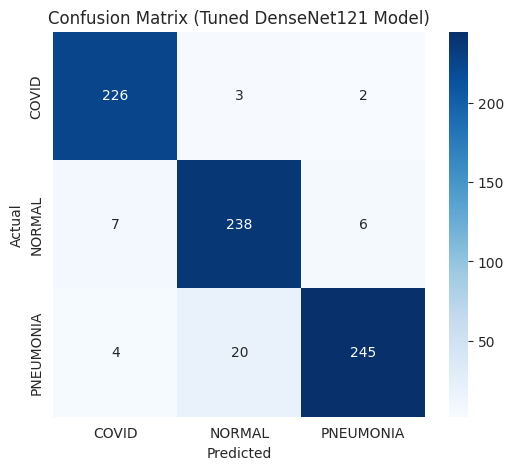

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(cm_tuned_densenet, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels_tuned_densenet,
            yticklabels=class_labels_tuned_densenet)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Tuned DenseNet121 Model)")
plt.show()

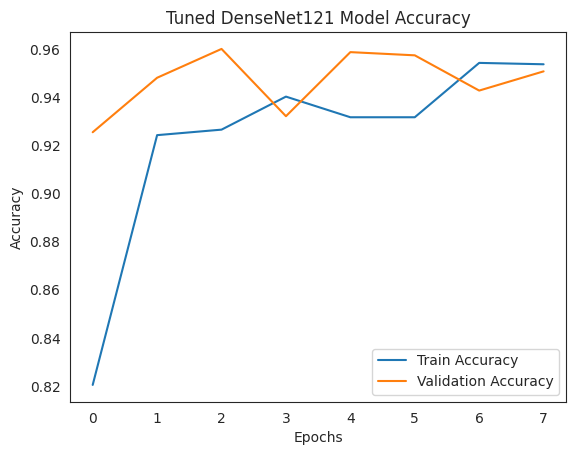

In [ ]:
if history_tuned_densenet:
    plt.plot(history_tuned_densenet.history['accuracy'], label='Train Accuracy')
    plt.plot(history_tuned_densenet.history['val_accuracy'], label='Validation Accuracy')

    plt.title("Tuned DenseNet121 Model Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()
else:
    print("Training history not available for Tuned DenseNet121 Model (model was loaded from disk or training was skipped).")

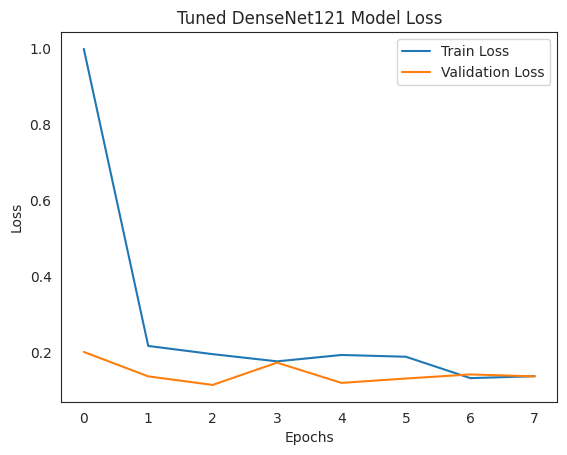

In [ ]:
if history_tuned_densenet:
    plt.plot(history_tuned_densenet.history['loss'], label='Train Loss')
    plt.plot(history_tuned_densenet.history['val_loss'], label='Validation Loss')

    plt.title("Tuned DenseNet121 Model Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()
else:
    print("Training history not available for Tuned DenseNet121 Model (model was loaded from disk or training was skipped).")

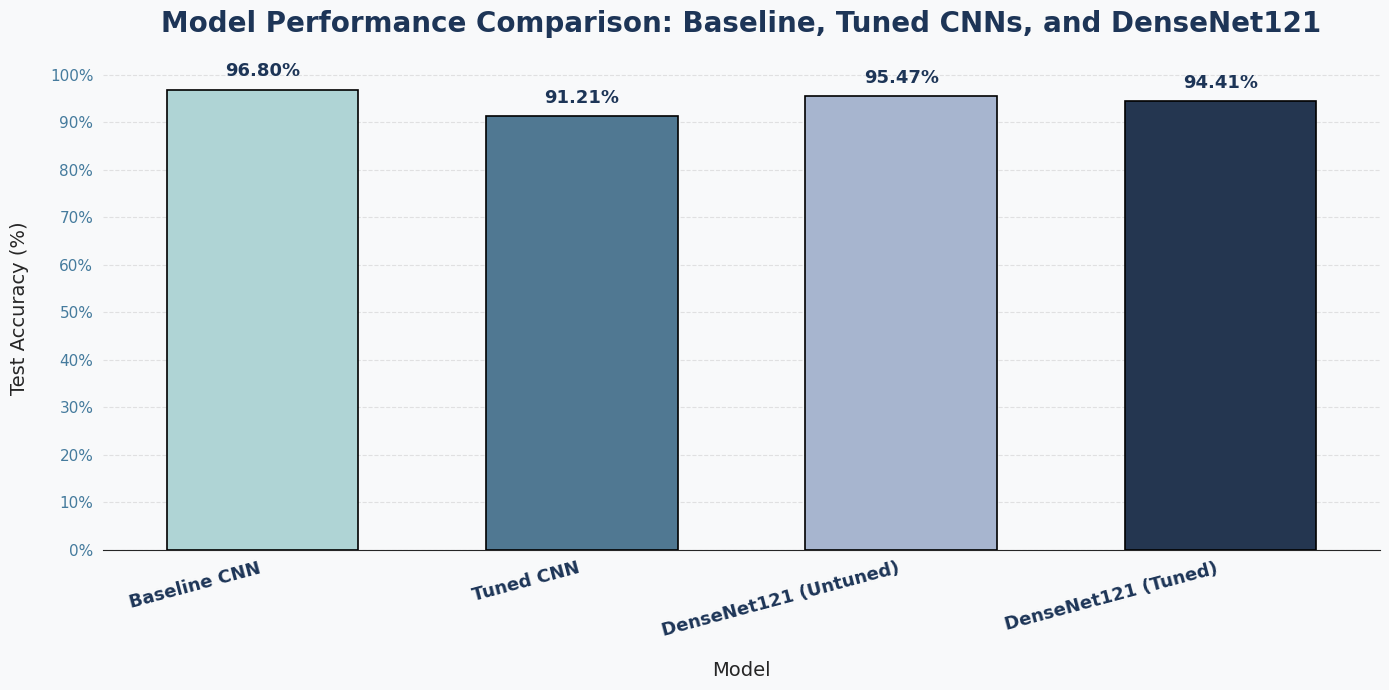

In [ ]:
model_names = ['Baseline CNN', 'Tuned CNN', 'DenseNet121 (Untuned)', 'DenseNet121 (Tuned)']
accuracies = [test_accuracy, test_accuracy_tuned, test_accuracy_densenet, test_accuracy_tuned_densenet]

sns.set_style("white")
plt.figure(figsize=(14, 7), facecolor='#F8F9FA')
ax = plt.gca()
ax.set_facecolor('#F8F9FA')
colors = ["#A8DADC", "#457B9D", "#A0B3D6", "#1D3557"]

barplot = sns.barplot(
    x=model_names,
    y=accuracies,
    hue=model_names,
    palette=colors,
    edgecolor='black',
    linewidth=1.2,
    legend=False,
    width=0.6
)

plt.title('Model Performance Comparison: Baseline, Tuned CNNs, and DenseNet121', fontsize=20, fontweight='bold', pad=25, color='#1D3557')
plt.ylabel('Test Accuracy (%)', fontsize=14, labelpad=15, fontweight='500')
plt.xlabel('Model', fontsize=14, labelpad=15, fontweight='500')

plt.yticks(np.arange(0, 1.1, 0.1), [f'{x*100:.0f}%' for x in np.arange(0, 1.1, 0.1)], fontsize=11, color='#457B9D')
plt.xticks(fontsize=13, fontweight='bold', color='#1D3557', rotation=15, ha='right') # Rotate for better label readability

ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.2)
sns.despine(left=True, bottom=False)

for p in barplot.patches:
    val = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2.,
        val + 0.02,
        f'{val:.2%}',
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight='bold',
        color='#1D3557'
    )
plt.tight_layout()
plt.show()

In [ ]:
save_dir = "/content/drive/MyDrive/saved_models"

baseline_checkpoint_dir = os.path.join(save_dir, "baseline_cnn", "checkpoints")
best_model_path = os.path.join(baseline_checkpoint_dir, "best_baseline_cnn_model.keras")

tuned_checkpoint_dir = os.path.join(save_dir, "tuned_cnn", "checkpoints")
best_model_path_tuned = os.path.join(tuned_checkpoint_dir, "best_tuned_cnn_model.keras")

densenet_checkpoint_dir = os.path.join(save_dir, "densenet121", "checkpoints")
best_densenet_model_path = os.path.join(densenet_checkpoint_dir, "best_densenet121_model.keras")

tuned_densenet_checkpoint_dir = os.path.join(save_dir, "tuned_densenet121", "checkpoints")
best_tuned_densenet_model_path = os.path.join(tuned_densenet_checkpoint_dir, "best_tuned_densenet121_model.keras")

loaded_baseline_cnn = tf.keras.models.load_model(best_model_path)
loaded_tuned_cnn = tf.keras.models.load_model(best_model_path_tuned)
loaded_densenet121 = tf.keras.models.load_model(best_densenet_model_path)
loaded_tuned_densenet121 = tf.keras.models.load_model(best_tuned_densenet_model_path)

print("All models loaded successfully:")
print(f"- Baseline CNN from: {best_model_path}")
print(f"- Tuned CNN from: {best_model_path_tuned}")
print(f"- DenseNet121 (Untuned) from: {best_densenet_model_path}")
print(f"- DenseNet121 (Tuned) from: {best_tuned_densenet_model_path}")

All models loaded successfully:
- Baseline CNN from: /content/drive/MyDrive/saved_models/baseline_cnn/checkpoints/best_baseline_cnn_model.keras
- Tuned CNN from: /content/drive/MyDrive/saved_models/tuned_cnn/checkpoints/best_tuned_cnn_model.keras
- DenseNet121 (Untuned) from: /content/drive/MyDrive/saved_models/densenet121/checkpoints/best_densenet121_model.keras
- DenseNet121 (Tuned) from: /content/drive/MyDrive/saved_models/tuned_densenet121/checkpoints/best_tuned_densenet121_model.keras


Upload an image (JPG, PNG, JPEG) to get a prediction and Grad-CAM visualization for the best performing model (Baseline CNN):


Saving 12341234.png to 12341234.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted: PNEUMONIA (Confidence: 99.96%)
Using last convolutional layer: conv2d_5


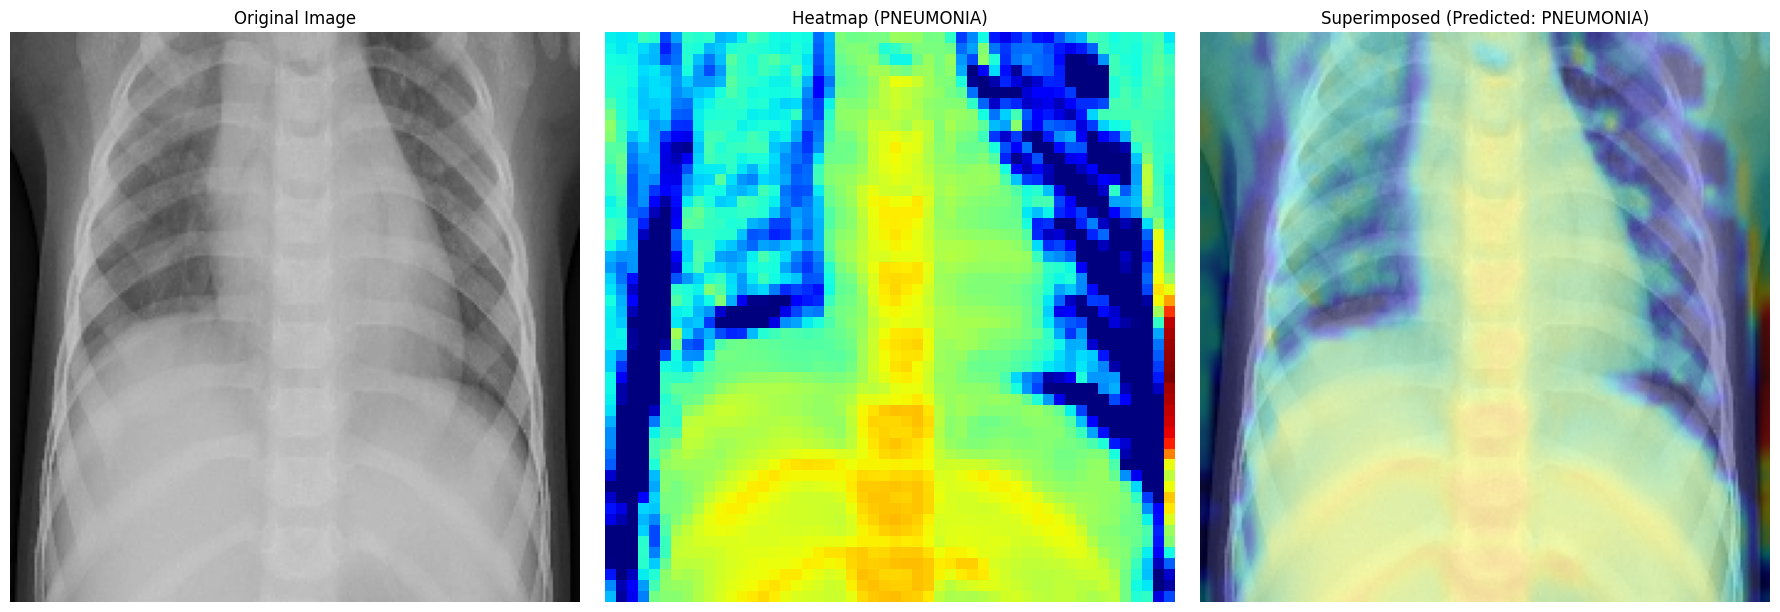

In [ ]:
from google.colab import files
import io

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model_features = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=model.get_layer(last_conv_layer_name).output
    )
    classifier_input_shape = grad_model_features.output.shape[1:]
    classifier_input = tf.keras.Input(shape=classifier_input_shape)

    x = classifier_input
    for layer in model.layers[model.layers.index(model.get_layer(last_conv_layer_name)) + 1:]:
        x = layer(x)
    grad_model_classifier = tf.keras.models.Model(inputs=classifier_input, outputs=x)

    with tf.GradientTape() as tape:
        last_conv_layer_output = grad_model_features(img_array)
        tape.watch(last_conv_layer_output)

        preds = grad_model_classifier(last_conv_layer_output)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img, heatmap, alpha=0.4):
    heatmap = np.uint8(255 * heatmap)

    jet = plt.colormaps["jet"]

    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    jet_heatmap = keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = keras.utils.img_to_array(jet_heatmap)

    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = keras.utils.array_to_img(superimposed_img)

    return superimposed_img

def predict_and_gradcam(uploaded_file, model, class_names, img_size):
    img = Image.open(io.BytesIO(uploaded_file)).convert("RGB")
    original_img_for_display = np.array(img)
    img_resized = img.resize(img_size)
    img_array = np.array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    _ = model(img_array)

    predictions = model.predict(img_array)
    predicted_class_idx = np.argmax(predictions)
    predicted_class_name = class_names[predicted_class_idx]
    confidence = np.max(predictions) * 100

    print(f"Predicted: {predicted_class_name} (Confidence: {confidence:.2f}%)")

    last_conv_layer_name = None
    for layer in reversed(model.layers):
        if isinstance(layer, (tf.keras.layers.Conv2D, tf.keras.layers.SeparableConv2D)):
            last_conv_layer_name = layer.name
            break

    if last_conv_layer_name is None:
        print("Could not find a convolutional layer in the model for Grad-CAM.")
        plt.figure(figsize=(6, 6))
        plt.imshow(original_img_for_display)
        plt.title(f"Prediction: {predicted_class_name} (Confidence: {confidence:.2f}%)वरुन")
        plt.axis('off')
        plt.show()
    else:
        print(f"Using last convolutional layer: {last_conv_layer_name}")
        heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name, predicted_class_idx)

        plt.figure(figsize=(18, 6))

        plt.subplot(1, 3, 1)
        plt.imshow(original_img_for_display)
        plt.title("Original Image")
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.imshow(heatmap, cmap='jet')
        plt.title(f"Heatmap ({predicted_class_name})")
        plt.axis('off')

        superimposed_img = display_gradcam(original_img_for_display, heatmap)
        plt.subplot(1, 3, 3)
        plt.imshow(superimposed_img)
        plt.title(f"Superimposed (Predicted: {predicted_class_name})")
        plt.axis('off')
        plt.tight_layout()
        plt.show()

img_size = (224, 224)
class_names = ['COVID', 'NORMAL', 'PNEUMONIA']

print("Upload an image (JPG, PNG, JPEG) to get a prediction and Grad-CAM visualization for the best performing model (Baseline CNN):")
uploaded = files.upload()

for fn in uploaded.keys():
    predict_and_gradcam(
        uploaded[fn],
        loaded_baseline_cnn,
        class_names,
        img_size
    )